# RQ2: Regression — Which Features Predict Developer Salary?

**Research Question:** Which developer characteristics — including years of experience, education, employment type, geographic location, and technology stack — most accurately predict annual compensation, and how much variance in developer salary can machine learning regression models explain?

**Task:** Regression  
**Target:** `log1p(ConvertedCompYearly)` (USD respondents, back-transformed for reporting)  
**Models:** Ridge (RidgeCV), Random Forest Regressor, XGBoost Regressor  
**Dataset:** Stack Overflow Annual Developer Survey 2025

In [34]:
import os
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
sns.set_palette(PALETTE)
RANDOM_STATE = 42
OUTPUT_DIR = '/kaggle/working/'

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f'Saved figure: {path}')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f'Saved table:  {path}')

def multihot_encode(series, top_n=15, prefix=''):
    all_vals = []
    for v in series.dropna():
        if v != 'NA':
            all_vals.extend([x.strip() for x in v.split(';')])
    top_vals = [v for v, _ in Counter(all_vals).most_common(top_n)]
    result = pd.DataFrame(index=series.index)
    for val in top_vals:
        col = f"{prefix}{val.replace(' ', '_').replace(',', '').replace('/', '_')}"
        result[col] = series.apply(
            lambda x: 1 if (isinstance(x, str) and x != 'NA' and val in x.split(';')) else 0
        )
    return result, top_vals

ORGSIZE_MAP = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    'Less than 20 employees': 2, '20 to 99 employees': 3,
    '100 to 499 employees': 4, '500 to 999 employees': 5,
    '1,000 to 4,999 employees': 6, '5,000 to 9,999 employees': 7,
    '10,000 or more employees': 8
}

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

print('Imports OK')

Imports OK


## 1. Data Loading

In [35]:
import glob
matches = glob.glob('/kaggle/input/**/survey_results_public.csv', recursive=True)
if not matches:
    raise FileNotFoundError('survey_results_public.csv not found under /kaggle/input/')
FILE_PATH = matches[0]
print('Using:', FILE_PATH)

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
print(f'Shape: {df.shape}')

Using: /kaggle/input/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025/survey_results_public.csv
Shape: (49123, 170)


## 2. Filtering & Target Engineering

In [36]:
# Keep USD respondents with valid salary
df_usd = df[df['Currency'].str.contains('USD', na=False)].copy()
df_usd['ConvertedCompYearly'] = pd.to_numeric(df_usd['ConvertedCompYearly'], errors='coerce')
df_usd = df_usd[(df_usd['ConvertedCompYearly'] > 0) & (df_usd['ConvertedCompYearly'] < 1_000_000)].copy()
print(f'USD respondents with valid salary: {df_usd.shape[0]}')
print(f'Salary stats (USD):')
print(df_usd['ConvertedCompYearly'].describe().round(0))

# Log transform target
df_usd['Salary_log'] = np.log1p(df_usd['ConvertedCompYearly'])

USD respondents with valid salary: 6285
Salary stats (USD):
count      6285.0
mean     146793.0
std      107479.0
min           1.0
25%       80000.0
50%      135000.0
75%      190000.0
max      980000.0
Name: ConvertedCompYearly, dtype: float64


## 3. Feature Engineering

In [37]:
df_usd['YearsCode'] = pd.to_numeric(df_usd['YearsCode'], errors='coerce')
df_usd['WorkExp']   = pd.to_numeric(df_usd['WorkExp'],   errors='coerce')
df_usd['OrgSize_num'] = df_usd['OrgSize'].map(ORGSIZE_MAP)

# Multi-hot: DevType (top 12)
devtype_mh, _ = multihot_encode(df_usd['DevType'], top_n=12, prefix='devtype_')
df_usd = pd.concat([df_usd.reset_index(drop=True), devtype_mh.reset_index(drop=True)], axis=1)

# Multi-hot: LanguageHaveWorkedWith (top 12)
lang_mh, _ = multihot_encode(df_usd['LanguageHaveWorkedWith'], top_n=12, prefix='lang_')
df_usd = pd.concat([df_usd, lang_mh.reset_index(drop=True)], axis=1)

# Country grouped: top 10 + Other
top_countries = df_usd['Country'].value_counts().head(10).index.tolist()
df_usd['Country_grouped'] = df_usd['Country'].apply(lambda x: x if x in top_countries else 'Other')

DEVTYPE_COLS = list(devtype_mh.columns)
LANG_COLS    = list(lang_mh.columns)

NUMERIC_FEATURES = ['YearsCode', 'WorkExp', 'OrgSize_num'] + DEVTYPE_COLS + LANG_COLS
CAT_FEATURES     = ['EdLevel', 'Employment', 'RemoteWork', 'Country_grouped']

for col in CAT_FEATURES:
    df_usd[col] = df_usd[col].fillna('Unknown')

X = df_usd[NUMERIC_FEATURES + CAT_FEATURES].copy()
y = df_usd['Salary_log'].copy()

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')

Features: 31 | Samples: 6285


## 4. Exploratory Data Analysis

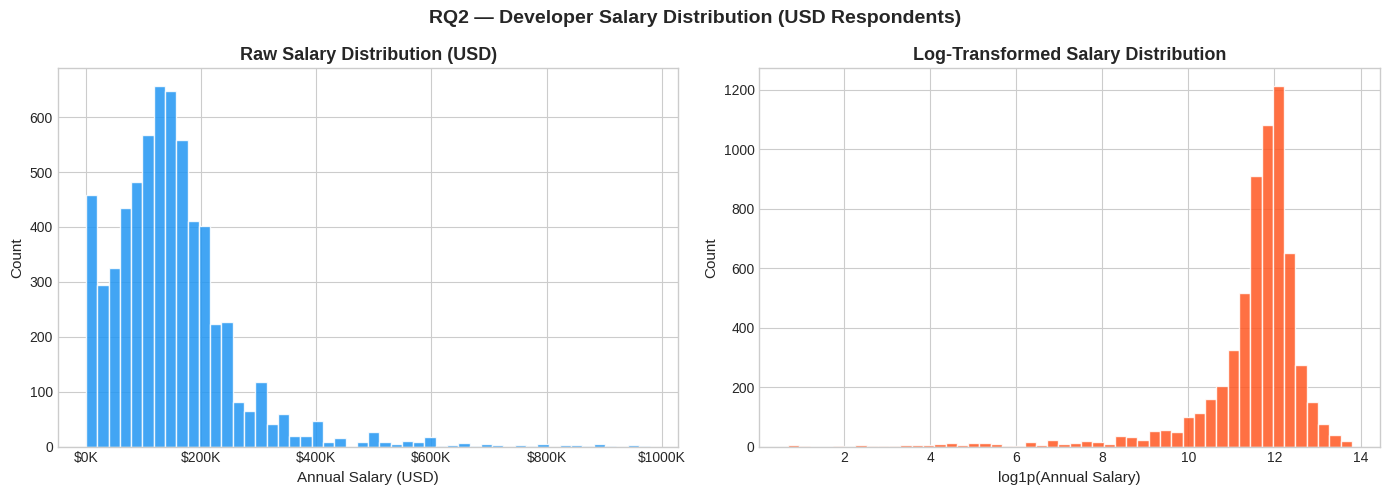

Saved figure: /kaggle/working/rq2_salary_distribution.pdf


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw salary distribution
axes[0].hist(df_usd['ConvertedCompYearly'], bins=50, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Annual Salary (USD)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Raw Salary Distribution (USD)', fontsize=13, fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Log-transformed distribution
axes[1].hist(df_usd['Salary_log'], bins=50, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log1p(Annual Salary)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Log-Transformed Salary Distribution', fontsize=13, fontweight='bold')

fig.suptitle('RQ2 — Developer Salary Distribution (USD Respondents)', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq2_salary_distribution.pdf')
plt.show()

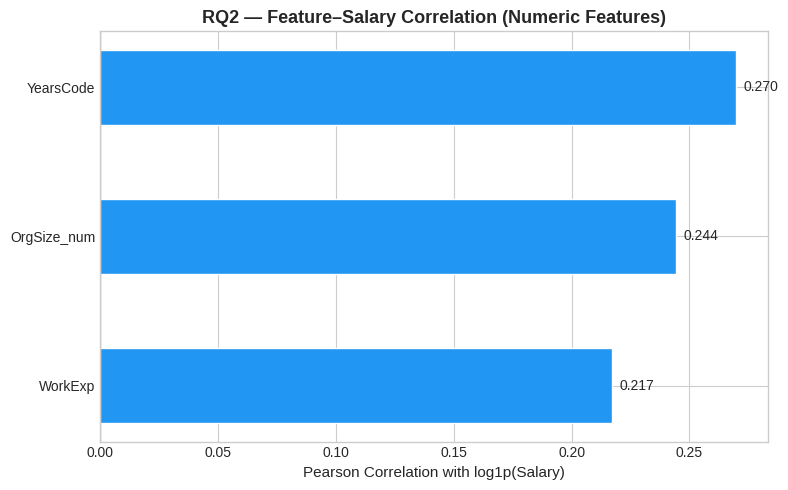

Saved figure: /kaggle/working/rq2_feature_salary_correlation.pdf


In [39]:
# Pearson correlation of numeric features with log salary
numeric_simple = ['YearsCode', 'WorkExp', 'OrgSize_num']
corr_data = df_usd[numeric_simple + ['Salary_log']].dropna()
corr_vals = corr_data.corr()['Salary_log'].drop('Salary_log').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = [PALETTE[1] if v < 0 else PALETTE[0] for v in corr_vals]
ax.barh(corr_vals.index, corr_vals.values, color=colors_corr, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with log1p(Salary)', fontsize=11)
ax.set_title('RQ2 — Feature–Salary Correlation (Numeric Features)', fontsize=13, fontweight='bold')
for i, (idx, val) in enumerate(corr_vals.items()):
    ax.text(val + (0.003 if val >= 0 else -0.003), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
save_figure(fig, 'rq2_feature_salary_correlation.pdf')
plt.show()

## 5. Preprocessing Pipeline & Train/Test Split

In [40]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', cat_transformer,     CAT_FEATURES)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (5028, 31) | Test: (1257, 31)


## 6. Model Training & Cross-Validation

In [41]:
models = {
    'Ridge (RidgeCV)':  RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
    'Random Forest':    RandomForestRegressor(n_estimators=300, max_depth=12,
                                              random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':          XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                     random_state=RANDOM_STATE, verbosity=0)
}

cv_kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}

for name, reg in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', reg)])
    t0 = time.time()
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv_kf, scoring='r2')
    pipe.fit(X_train, y_train)
    train_time = round(time.time() - t0, 2)
    fitted_models[name] = pipe

    y_pred_log = pipe.predict(X_test)
    y_pred     = np.expm1(y_pred_log)
    y_true     = np.expm1(y_test)

    n, p = X_test.shape[0], X_train.shape[1]
    r2 = r2_score(y_test, y_pred_log)

    results.append({
        'Model':         name,
        'RMSE':          round(np.sqrt(mean_squared_error(y_true, y_pred)), 0),
        'MAE':           round(mean_absolute_error(y_true, y_pred), 0),
        'R2':            round(r2, 4),
        'Adj_R2':        round(adj_r2(r2, n, p), 4),
        'MAPE_pct':      round(mape(y_true, y_pred), 2),
        'CV_R2_Mean':    round(cv_r2.mean(), 4),
        'CV_R2_Std':     round(cv_r2.std(), 4),
        'Train_Time_s':  train_time
    })
    print(f"{name}: R²={results[-1]['R2']}  RMSE=${results[-1]['RMSE']:,.0f}  MAPE={results[-1]['MAPE_pct']}%")

results_df = pd.DataFrame(results)
results_df

Ridge (RidgeCV): R²=0.2783  RMSE=$96,534  MAPE=6516.7%
Random Forest: R²=0.2881  RMSE=$97,055  MAPE=8840.3%
XGBoost: R²=0.293  RMSE=$92,738  MAPE=6971.18%


,Model,RMSE,MAE,R2,Adj_R2,MAPE_pct,CV_R2_Mean,CV_R2_Std,Train_Time_s
0,Ridge (RidgeCV),96534.0,60620.0,0.2783,0.2601,6516.70,0.3061,0.0185,0.36
1,Random Forest,97055.0,57967.0,0.2881,0.2701,8840.30,0.2804,0.0427,9.14
2,XGBoost,92738.0,56225.0,0.2930,0.2751,6971.18,0.2444,0.0413,1.58


## 7. Publication-Ready Figures

Best model: XGBoost


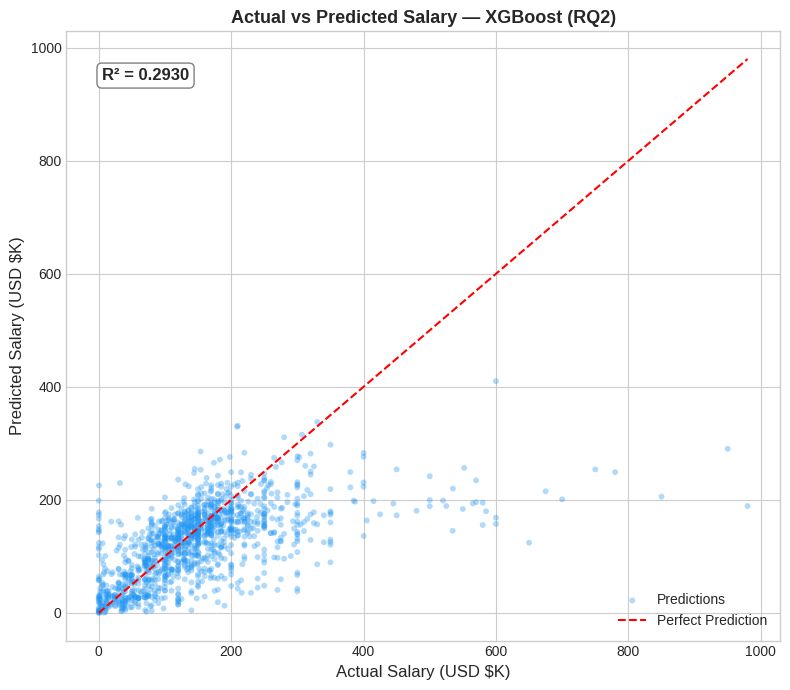

Saved figure: /kaggle/working/rq2_actual_vs_predicted.pdf


In [42]:
best_name = results_df.loc[results_df['R2'].idxmax(), 'Model']
best_pipe = fitted_models[best_name]
print(f'Best model: {best_name}')

y_pred_log = best_pipe.predict(X_test)
y_pred_usd = np.expm1(y_pred_log)
y_true_usd = np.expm1(y_test)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_true_usd / 1000, y_pred_usd / 1000, alpha=0.35, s=18,
           color=PALETTE[0], edgecolors='none', label='Predictions')
max_val = max(y_true_usd.max(), y_pred_usd.max()) / 1000
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
r2_val = r2_score(y_test, y_pred_log)
ax.text(0.05, 0.92, f'R² = {r2_val:.4f}', transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
ax.set_xlabel('Actual Salary (USD $K)', fontsize=12)
ax.set_ylabel('Predicted Salary (USD $K)', fontsize=12)
ax.set_title(f'Actual vs Predicted Salary — {best_name} (RQ2)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
save_figure(fig, 'rq2_actual_vs_predicted.pdf')
plt.show()

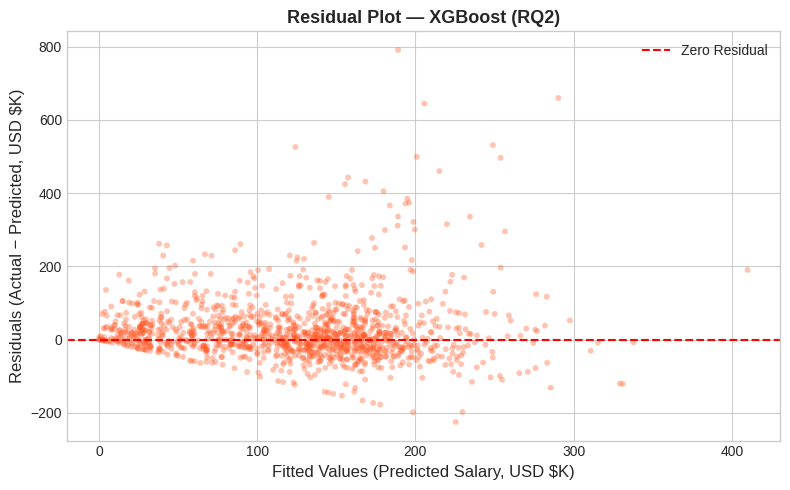

Saved figure: /kaggle/working/rq2_residual_plot.pdf


In [43]:
residuals = y_true_usd - y_pred_usd

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_usd / 1000, residuals / 1000, alpha=0.35, s=18,
           color=PALETTE[1], edgecolors='none')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Zero Residual')
ax.set_xlabel('Fitted Values (Predicted Salary, USD $K)', fontsize=12)
ax.set_ylabel('Residuals (Actual − Predicted, USD $K)', fontsize=12)
ax.set_title(f'Residual Plot — {best_name} (RQ2)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
save_figure(fig, 'rq2_residual_plot.pdf')
plt.show()

In [44]:
save_table(results_df, 'rq2_model_comparison.csv')
results_df

Saved table:  /kaggle/working/rq2_model_comparison.csv


,Model,RMSE,MAE,R2,Adj_R2,MAPE_pct,CV_R2_Mean,CV_R2_Std,Train_Time_s
0,Ridge (RidgeCV),96534.0,60620.0,0.2783,0.2601,6516.70,0.3061,0.0185,0.36
1,Random Forest,97055.0,57967.0,0.2881,0.2701,8840.30,0.2804,0.0427,9.14
2,XGBoost,92738.0,56225.0,0.2930,0.2751,6971.18,0.2444,0.0413,1.58


## 8. Conclusions

In [45]:
best_row = results_df.loc[results_df['R2'].idxmax()]
print('=' * 60)
print('RQ2 CONCLUSION')
print('=' * 60)
print(f'Best model:  {best_row["Model"]}')
print(f'  R²:        {best_row["R2"]}')
print(f'  Adj R²:    {best_row["Adj_R2"]}')
print(f'  RMSE:      ${best_row["RMSE"]:,.0f}')
print(f'  MAE:       ${best_row["MAE"]:,.0f}')
print(f'  MAPE:      {best_row["MAPE_pct"]}%')
print()
print('Output files saved to /kaggle/working/:')
print('  rq2_salary_distribution.pdf')
print('  rq2_feature_salary_correlation.pdf')
print('  rq2_actual_vs_predicted.pdf')
print('  rq2_residual_plot.pdf')
print('  rq2_model_comparison.csv')

RQ2 CONCLUSION
Best model:  XGBoost
  R²:        0.293
  Adj R²:    0.2751
  RMSE:      $92,738
  MAE:       $56,225
  MAPE:      6971.18%

Output files saved to /kaggle/working/:
  rq2_salary_distribution.pdf
  rq2_feature_salary_correlation.pdf
  rq2_actual_vs_predicted.pdf
  rq2_residual_plot.pdf
  rq2_model_comparison.csv
